In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from jiflr import ROOT
from jiflr.data import select_sensors, merge_sensor_datasets
from jiflr.utils import butterworth_filter, calculate_lapse_rate_timestep, lapse_rate_ufunc
from scipy import stats
import os


plt.style.use("default")
plt.ioff()

# Initial Lapse Rate Analysis

Calculate time-varying lapse rates between maritime and continental site groups using lvl1 sensor data. This analysis computes hourly lapse rates over the temporal period where all sites have overlapping data coverage.

In [3]:
# Load pendant data
ds_pendants = xr.open_dataset(ROOT / "data/2025/processed/lvl1/lvl1_on_ice.nc")
ds_pendants = select_sensors(ds_pendants, height="2m", shielding="shielded")

# Drop sensors missing coordinates (e.g. G03A, G03B)
ds_pendants = ds_pendants.isel(sensor_idx=~np.isnan(ds_pendants.latitude.values))

# Load intensive site data and filter to shielded pendants
ds_intensive = xr.open_dataset(
    ROOT / "data/2025/processed/lvl1/lvl1_on_ice_intensive.nc"
)
ds_intensive = select_sensors(ds_intensive, height="2m", shielding="shielded")

# Merge datasets
ds = merge_sensor_datasets(ds_pendants, ds_intensive)

print(f"Dataset dimensions: {dict(ds.sizes)}")
print(f"Dataset variables: {list(ds.data_vars)}")
print(f"Available site_ids: {sorted(ds.site_id.values.tolist())}")

Dataset dimensions: {'datetime': 25578, 'sensor_idx': 29}
Dataset variables: ['temp_c', 'intensity_lux']
Available site_ids: ['A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A10', 'B01', 'B02', 'B03', 'C02', 'D01', 'D02', 'D04', 'Divide', 'E01', 'E03', 'E04', 'F03', 'F05', 'F06', 'G01', 'G02', 'G04', 'Lee1', 'Lee2', 'Windward1', 'Windward2']


In [4]:
# Configure Butterworth filter for plotting
# For 5-minute data: fs = 1/300 Hz (sampling frequency)
# upper = 1/6 means cutoff at 6 samples = 30 minutes

FILTER_ORDER = 4
FILTER_LOWER = None  # Low-pass filter only
# FILTER_FS = 1 / 300  # Sampling frequency for 5-minute data (1 sample per 300 seconds)
# FILTER_UPPER = 1 / (60 * 60)  # 1 hr cutoff
FILTER_UPPER = 1 / (2 * 60 * 60)  # 2 hr cutoff

# For 15-min data: fs = 1/(300 * 3) Hz
FILTER_FS = 1 / (300 * 3)




# ============================================================================
# COLOR CONFIGURATION
# ============================================================================
# Configure color scheme for all plots using cmocean tarn colormap
# Maritime: warm colors (higher values in tarn colormap)
# Continental: cool colors (lower values in tarn colormap)
# Difference: neutral grey

# Single color configurations
MARITIME_COLOR = "blue"  # Single maritime color
CONTINENTAL_COLOR = "red"  # Single continental color
DIFFERENCE_COLOR = "purple"  # Color for difference plots

MARITIME_COLORS = [plt.cm.viridis(0.8), plt.cm.viridis(0.5), plt.cm.viridis(0.2)]
CONTINENTAL_COLORS = [plt.cm.magma(0.8), plt.cm.magma(0.6), plt.cm.magma(0.4)]


# Color mapping functions for easier use
def get_maritime_color(index=0):
    """Get maritime color by index, cycling through available colors"""
    return MARITIME_COLORS[index % len(MARITIME_COLORS)]


def get_continental_color(index=0):
    """Get continental color by index, cycling through available colors"""
    return CONTINENTAL_COLORS[index % len(CONTINENTAL_COLORS)]




def determine_axis_limits(data_series):
    """
    Determine axis limits using min and max values.

    Parameters:
    -----------
    data_series : pandas.Series or xarray.DataArray
        The data series to analyze

    Returns:
    --------
    tuple : (min_val, max_val) for axis limits
    """
    if data_series is None:
        return (0, 1)  # Default fallback

    # Convert to pandas if needed and drop NaN values
    if hasattr(data_series, "to_pandas"):
        clean_data = data_series.to_pandas().dropna()
    else:
        clean_data = data_series.dropna()

    if len(clean_data) == 0:
        return (0, 1)  # Default fallback for empty data

    # Calculate min and max
    data_min = clean_data.min()
    data_max = clean_data.max()

    # Add small buffer (5% of range)
    data_range = data_max - data_min
    buffer = data_range * 0.05

    return (data_min - buffer, data_max + buffer)

In [5]:
# Define site groups based on the available site_ids
# Note: We'll need to map the requested site names to actual site_ids in the dataset

# Maritime sites (as requested): Windward1, Windward2, A04, A05, A06, Divide
# Continental sites (as requested): A07, Lee1, Lee2, A08, A10

# Note: The dataset uses 'Wind' and 'Divi' but we need to separate Wind into Windward1/Windward2
# and rename Divi to Divide for proper site naming
maritime_sites = [
    "Windward1",
    "Windward2",
    "A05",
    "A06",
    "A07",
    "Divide",
]
continental_sites = ["Divide", "Lee1", "Lee2", "A08"]  # A10 removed

print("Requested maritime sites:", maritime_sites)
print(
    "Available maritime sites found:",
    [s for s in maritime_sites if s in ds.site_id.values],
)
print("Requested continental sites:", continental_sites)
print(
    "Available continental sites found:",
    [s for s in continental_sites if s in ds.site_id.values],
)

# Get the union of all sites needed for analysis
all_analysis_sites = maritime_sites + continental_sites
print(f"All analysis sites: {all_analysis_sites}")

Requested maritime sites: ['Windward1', 'Windward2', 'A05', 'A06', 'A07', 'Divide']
Available maritime sites found: ['Windward1', 'Windward2', 'A05', 'A06', 'A07', 'Divide']
Requested continental sites: ['Divide', 'Lee1', 'Lee2', 'A08']
Available continental sites found: ['Divide', 'Lee1', 'Lee2', 'A08']
All analysis sites: ['Windward1', 'Windward2', 'A05', 'A06', 'A07', 'Divide', 'Divide', 'Lee1', 'Lee2', 'A08']


In [6]:
# Filter the dataset to include only our analysis sites and apply sensor filtering
da = ds.temp_c
analysis_mask = da.site_id.isin(all_analysis_sites)
da = da.where(analysis_mask, drop=True)

# Mask to period of overlapping data
has_data = da.notnull().all(dim="sensor_idx")
da_overlap = da.sel(datetime=has_data)



# Resample to hourly data over the overlap period
print("Resampling...")

# Resample to 5-minute intervals, with custom aggregation for wind_speed_peak
# Most variables use mean resampling
da_hourly = da_overlap.resample(datetime="15min").mean()





# Test the function with the first timestep
test_timestep = 0
temp_at_t0 = da_hourly.isel(datetime=test_timestep).values
elev_data = da_hourly.elevation.values

# Create masks for maritime and continental sites
maritime_mask = da_hourly.site_id.isin(maritime_sites).values
continental_mask = da_hourly.site_id.isin(continental_sites).values

print(f"Maritime sites mask: {maritime_mask.sum()} sites")
print(f"Continental sites mask: {continental_mask.sum()} sites")

# Test the function
mar_slope, mar_intercept = calculate_lapse_rate_timestep(
    temp_at_t0, elev_data, maritime_mask
)
cont_slope, cont_intercept = calculate_lapse_rate_timestep(
    temp_at_t0, elev_data, continental_mask
)

print(f"Test maritime lapse rate: {mar_slope:.6f} °C/m ({mar_slope * 1000:.3f} °C/km)")
print(
    f"Test continental lapse rate: {cont_slope:.6f} °C/m ({cont_slope * 1000:.3f} °C/km)"
)





print("Calculating maritime lapse rates...")
# Apply to maritime sites
maritime_slopes, maritime_intercepts = xr.apply_ufunc(
    lapse_rate_ufunc,
    da_hourly,
    da_hourly.elevation,
    maritime_mask,
    input_core_dims=[["datetime", "sensor_idx"], ["sensor_idx"], []],
    output_core_dims=[["datetime"], ["datetime"]],
    output_dtypes=[float, float],
    dask="forbidden",  # Disable dask for simplicity
)

print("Calculating continental lapse rates...")
# Apply to continental sites
continental_slopes, continental_intercepts = xr.apply_ufunc(
    lapse_rate_ufunc,
    da_hourly,
    da_hourly.elevation,
    continental_mask,
    input_core_dims=[["datetime", "sensor_idx"], ["sensor_idx"], []],
    output_core_dims=[["datetime"], ["datetime"]],
    output_dtypes=[float, float],
    dask="forbidden",  # Disable dask for simplicity
)

print("Lapse rate calculation completed!")



# Add the calculated lapse rates and intercepts as data variables to the dataset
print("Adding lapse rate variables to dataset...")

# Create DataArrays with proper coordinates and attributes
maritime_lapse_rate = xr.DataArray(
    maritime_slopes,
    coords={"datetime": da_hourly.datetime},
    dims=["datetime"],
    name="maritime_lapse_rate",
    attrs={
        "long_name": "Maritime sites temperature lapse rate",
        "units": "degrees_C/m",
        "description": f"Linear regression slope for temperature vs elevation for maritime sites: {maritime_sites}",
        "sites_included": ", ".join(maritime_sites),
        "calculation_method": "hourly linear regression using scipy.stats.linregress",
    },
)

maritime_intercept = xr.DataArray(
    maritime_intercepts,
    coords={"datetime": da_hourly.datetime},
    dims=["datetime"],
    name="maritime_intercept",
    attrs={
        "long_name": "Maritime sites temperature lapse rate intercept",
        "units": "degrees_C",
        "description": f"Linear regression intercept for temperature vs elevation for maritime sites: {maritime_sites}",
        "sites_included": ", ".join(maritime_sites),
        "calculation_method": "hourly linear regression using scipy.stats.linregress",
    },
)

continental_lapse_rate = xr.DataArray(
    continental_slopes,
    coords={"datetime": da_hourly.datetime},
    dims=["datetime"],
    name="continental_lapse_rate",
    attrs={
        "long_name": "Continental sites temperature lapse rate",
        "units": "degrees_C/m",
        "description": f"Linear regression slope for temperature vs elevation for continental sites: {continental_sites}",
        "sites_included": ", ".join(continental_sites),
        "calculation_method": "hourly linear regression using scipy.stats.linregress",
    },
)

continental_intercept = xr.DataArray(
    continental_intercepts,
    coords={"datetime": da_hourly.datetime},
    dims=["datetime"],
    name="continental_intercept",
    attrs={
        "long_name": "Continental sites temperature lapse rate intercept",
        "units": "degrees_C",
        "description": f"Linear regression intercept for temperature vs elevation for continental sites: {continental_sites}",
        "sites_included": ", ".join(continental_sites),
        "calculation_method": "hourly linear regression using scipy.stats.linregress",
    },
)

# Add to the hourly dataset
ds = da_hourly.to_dataset()
ds["maritime_lapse_rate"] = maritime_lapse_rate
ds["maritime_intercept"] = maritime_intercept
ds["continental_lapse_rate"] = continental_lapse_rate
ds["continental_intercept"] = continental_intercept

print("Lapse rate variables added successfully!")
print(f"Dataset variables: {list(ds.data_vars)}")



# Check available sites and their elevations for proper mapping
print("Site mapping and elevation data:")
unique_sites = da_hourly.site_id.values
unique_elevations = da_hourly.elevation.values

# Create a site-elevation mapping
site_elev_pairs = list(zip(unique_sites, unique_elevations))
site_elev_dict = {}
for site, elev in site_elev_pairs:
    if site not in site_elev_dict:
        site_elev_dict[site] = elev

print("Available sites with elevations:")
for site in sorted(site_elev_dict.keys()):
    print(f"  {site}: {site_elev_dict[site]:.0f}m")

# Sort maritime and continental sites by elevation
maritime_site_elevs = [
    (site, site_elev_dict[site]) for site in maritime_sites if site in site_elev_dict
]
continental_site_elevs = [
    (site, site_elev_dict[site]) for site in continental_sites if site in site_elev_dict
]

maritime_sorted = sorted(
    maritime_site_elevs, key=lambda x: x[1], reverse=True
)  # High to low
continental_sorted = sorted(
    continental_site_elevs, key=lambda x: x[1], reverse=True
)  # High to low

print("\nMaritime sites (high to low elevation):")
for site, elev in maritime_sorted:
    print(f"  {site}: {elev:.0f}m")

print("\nContinental sites (high to low elevation):")
for site, elev in continental_sorted:
    print(f"  {site}: {elev:.0f}m")

# Define highest, middle, lowest for each group
maritime_highest = maritime_sorted[0][0] if maritime_sorted else None
maritime_middle = (
    maritime_sorted[len(maritime_sorted) // 2][0] if len(maritime_sorted) > 1 else None
)
maritime_lowest = maritime_sorted[-1][0] if maritime_sorted else None

continental_highest = continental_sorted[0][0] if continental_sorted else None
continental_middle = (
    continental_sorted[len(continental_sorted) // 2][0]
    if len(continental_sorted) > 1
    else None
)
continental_lowest = continental_sorted[-1][0] if continental_sorted else None

print(f"\nMaritime group selection:")
print(f"  Highest: {maritime_highest}")
print(f"  Middle: {maritime_middle}")
print(f"  Lowest: {maritime_lowest}")

print(f"\nContinental group selection:")
print(f"  Highest: {continental_highest}")
print(f"  Middle: {continental_middle}")
print(f"  Lowest: {continental_lowest}")




# Helper function for pairwise lapse rate calculations
def calculate_pairwise_lapse_rate(ds, site1, site2, time_slice=None):
    """
    Calculate lapse rate between two specific sites for a given time period.

    Parameters:
    - ds: xarray dataset with temperature and elevation data
    - site1: first site ID
    - site2: second site ID
    - time_slice: optional slice object to filter time period

    Returns:
    - lapse_rates: xarray DataArray with lapse rates over time (°C/m)
    """

    # Apply time slice if provided
    if time_slice is not None:
        ds_subset = ds.sel(datetime=time_slice)
    else:
        ds_subset = ds

    # Get data for both sites
    site1_data = ds_subset.where(ds_subset.site_id == site1, drop=True)
    site2_data = ds_subset.where(ds_subset.site_id == site2, drop=True)

    # Get temperatures and elevations (take mean if multiple sensors per site)
    temp1 = site1_data.temp_c.mean("sensor_idx")
    temp2 = site2_data.temp_c.mean("sensor_idx")
    elev1 = float(site1_data.elevation.mean().values)
    elev2 = float(site2_data.elevation.mean().values)

    # Calculate lapse rate: (T2 - T1) / (elev2 - elev1)
    elev_diff = elev2 - elev1
    if abs(elev_diff) < 1e-6:  # Avoid division by zero
        return xr.full_like(temp1, np.nan)

    lapse_rate = (temp2 - temp1) / elev_diff

    return lapse_rate


# Test the function
print("Testing pairwise lapse rate calculation...")
if maritime_highest and maritime_lowest:
    test_lapse = calculate_pairwise_lapse_rate(ds, maritime_highest, maritime_lowest)
    print(
        f"Test lapse rate between {maritime_highest} and {maritime_lowest}: {test_lapse.mean().values:.6f} °C/m"
    )
    print(f"In °C/km: {test_lapse.mean().values * 1000:.3f} °C/km")



#
print("Summary of calculated lapse rates:")
print("\nMaritime lapse rate (°C/m):")
print(f"  Mean: {ds.maritime_lapse_rate.mean().values:.6f}")
print(f"  Std:  {ds.maritime_lapse_rate.std().values:.6f}")
print(f"  Min:  {ds.maritime_lapse_rate.min().values:.6f}")
print(f"  Max:  {ds.maritime_lapse_rate.max().values:.6f}")
print(f"  Valid: {ds.maritime_lapse_rate.count().values}/{len(ds.datetime)} hours")

print("\nContinental lapse rate (°C/m):")
print(f"  Mean: {ds.continental_lapse_rate.mean().values:.6f}")
print(f"  Std:  {ds.continental_lapse_rate.std().values:.6f}")
print(f"  Min:  {ds.continental_lapse_rate.min().values:.6f}")
print(f"  Max:  {ds.continental_lapse_rate.max().values:.6f}")
print(f"  Valid: {ds.continental_lapse_rate.count().values}/{len(ds.datetime)} hours")

# Convert to °C/km for easier interpretation
print("\nIn °C/km:")
print(f"Maritime mean: {ds.maritime_lapse_rate.mean().values * 1000:.3f} °C/km")
print(f"Continental mean: {ds.continental_lapse_rate.mean().values * 1000:.3f} °C/km")

Resampling...
Maritime sites mask: 6 sites
Continental sites mask: 4 sites
Test maritime lapse rate: 0.009436 °C/m (9.436 °C/km)
Test continental lapse rate: 0.005235 °C/m (5.235 °C/km)
Calculating maritime lapse rates...
Calculating continental lapse rates...
Lapse rate calculation completed!
Adding lapse rate variables to dataset...
Lapse rate variables added successfully!
Dataset variables: ['temp_c', 'maritime_lapse_rate', 'maritime_intercept', 'continental_lapse_rate', 'continental_intercept']
Site mapping and elevation data:
Available sites with elevations:
  A05: 1300m
  A06: 1544m
  A07: 1825m
  A08: 1767m
  Divide: 1858m
  Lee1: 1701m
  Lee2: 1400m
  Windward1: 1751m
  Windward2: 1405m

Maritime sites (high to low elevation):
  Divide: 1858m
  A07: 1825m
  Windward1: 1751m
  A06: 1544m
  Windward2: 1405m
  A05: 1300m

Continental sites (high to low elevation):
  Divide: 1858m
  A08: 1767m
  Lee1: 1701m
  Lee2: 1400m

Maritime group selection:
  Highest: Divide
  Middle: A06
  

/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_37992/4104325476.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_37992/4104325476.py:184: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


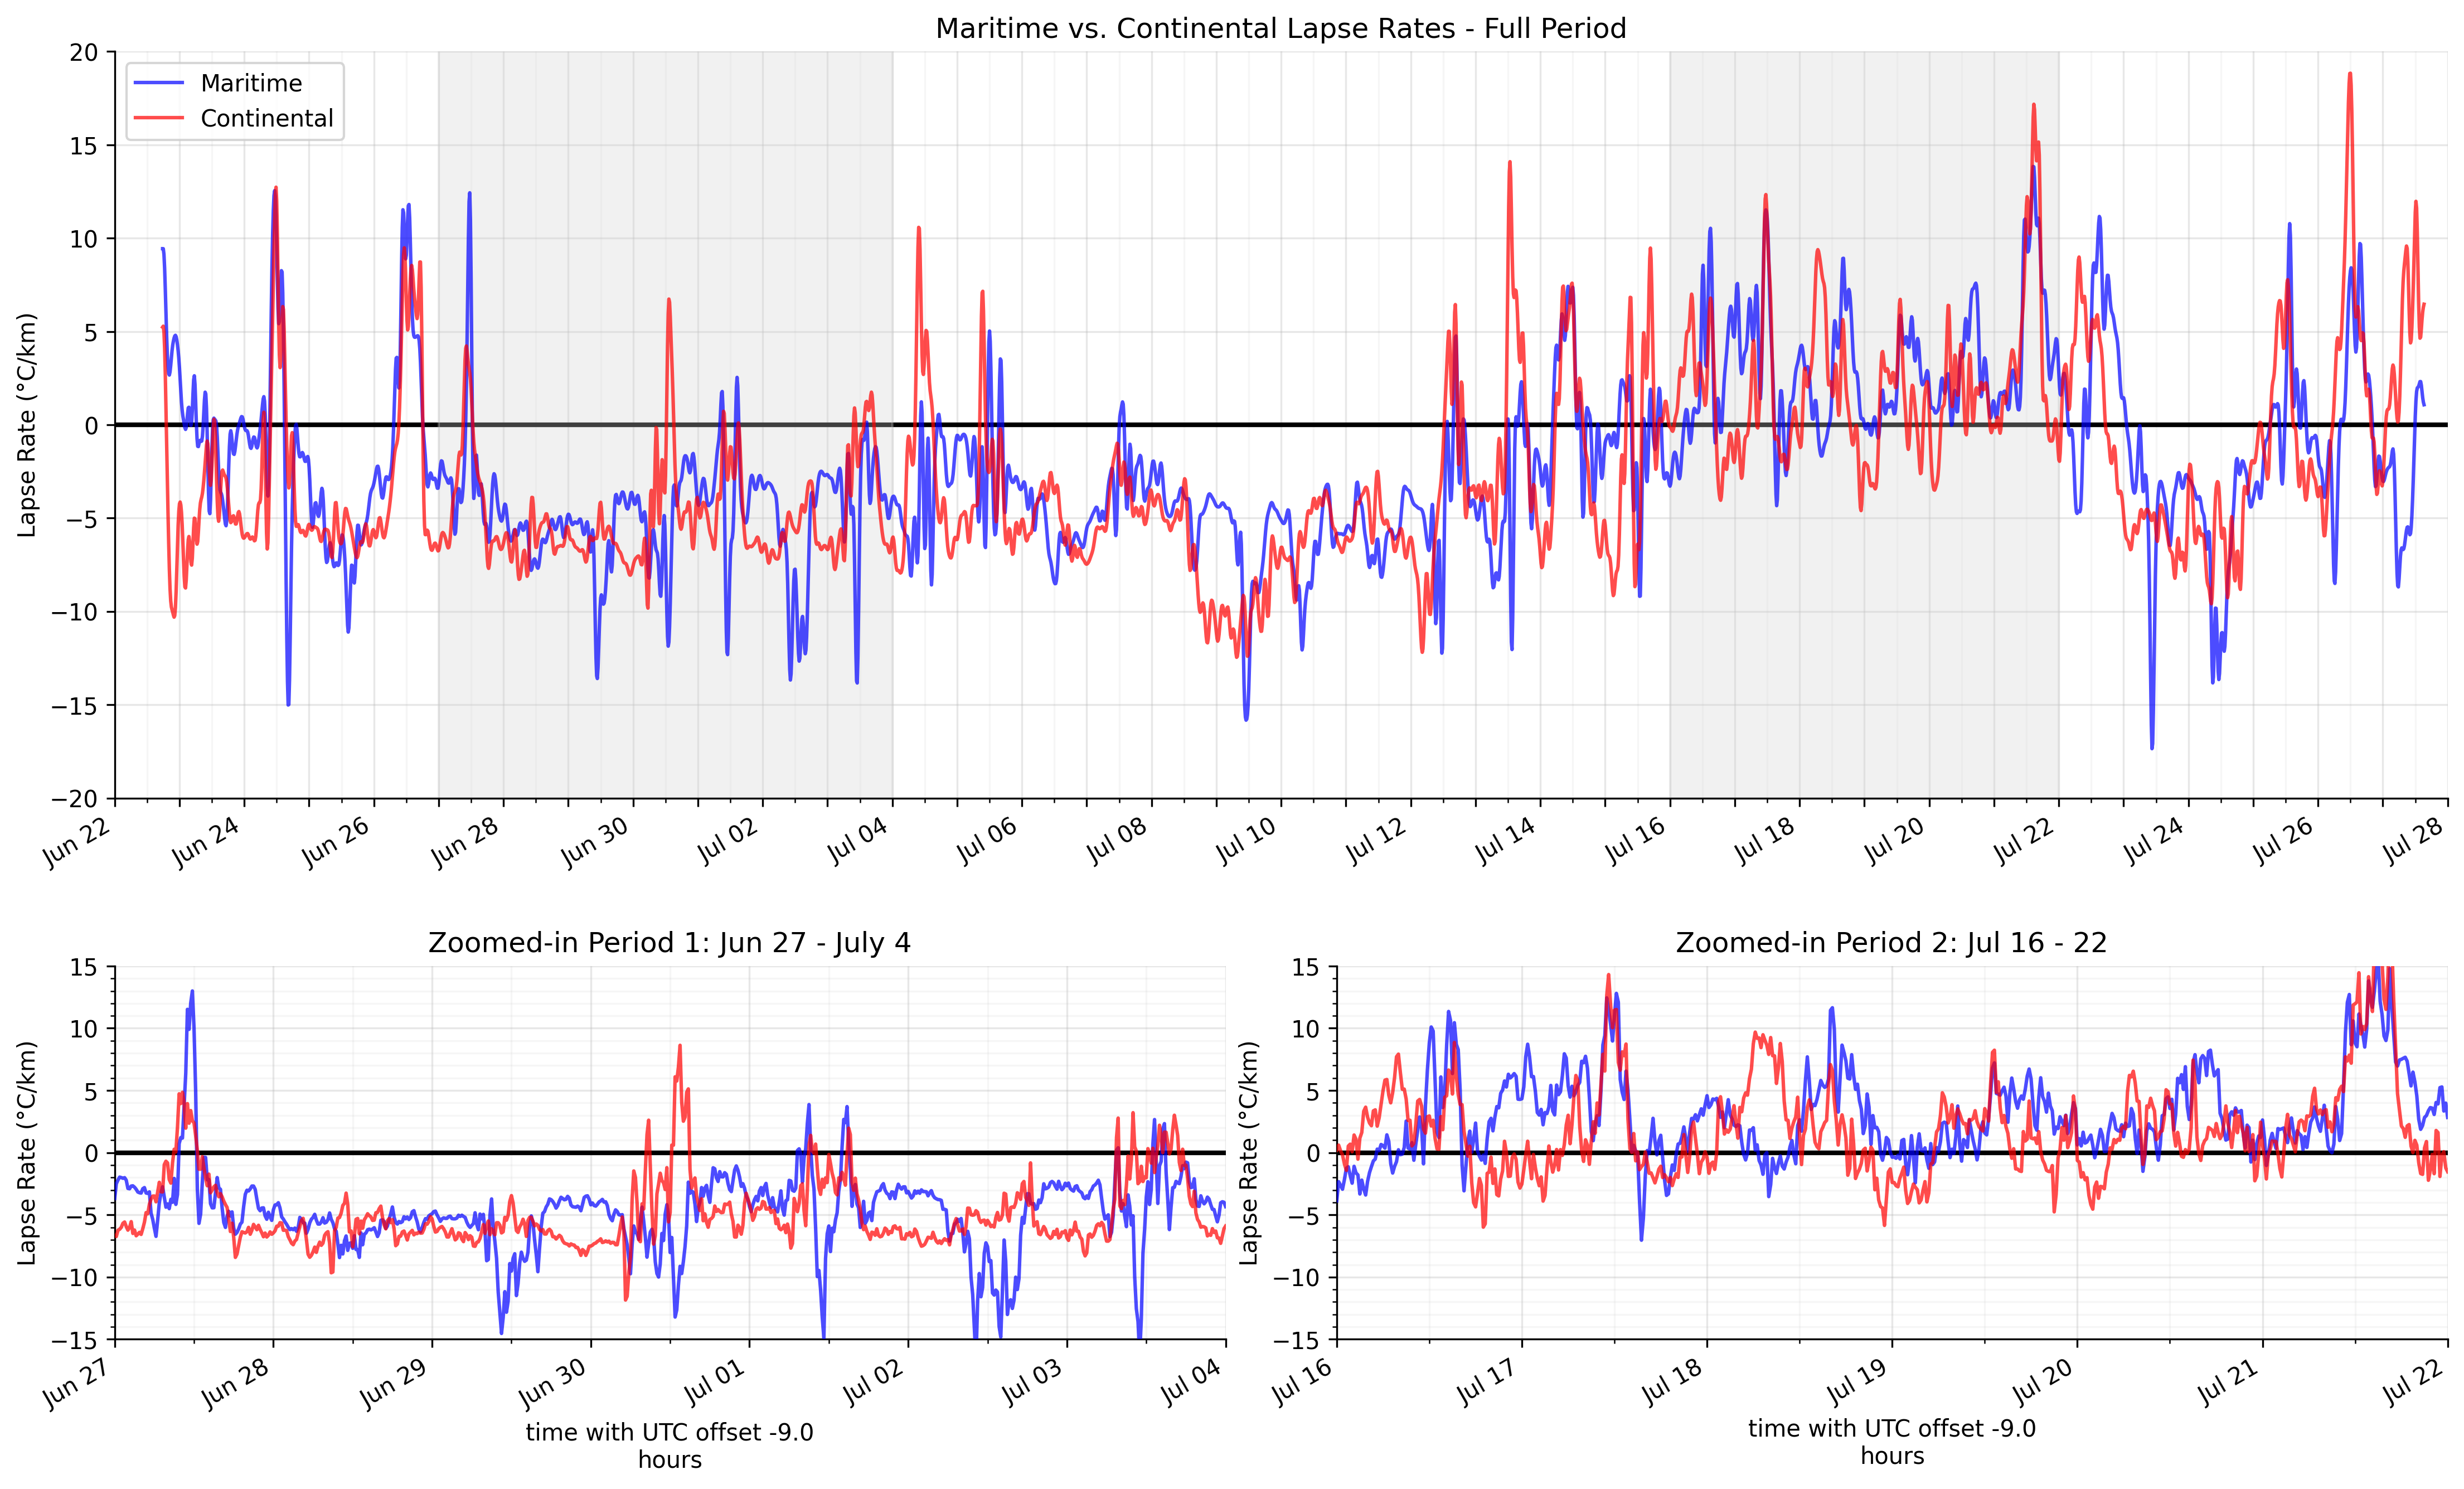

In [8]:
# ============================================================================
# FIGURE 4
# ============================================================================

# Import additional modules for axis formatting
from matplotlib.dates import DateFormatter, DayLocator, HourLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.gridspec as gridspec

# Create time series plots with gridspec layout:
# 1. Full period view (top row, spans full width)
# 2. Two side-by-side zoom plots (bottom row)
fig = plt.figure(figsize=(18, 10), dpi=300, layout="constrained")
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1], hspace=0.3, wspace=0.1, figure=fig)

# Top plot spans both columns
ax1 = fig.add_subplot(gs[0, :])
# Bottom plots are side-by-side
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

axes = [ax1, ax2, ax3]

# Define time slices for zoomed views
june_end_start = pd.Timestamp("2025-06-27")
june_end_end = pd.Timestamp("2025-07-04")  # Up to but not including July 1
june_end_slice = slice(june_end_start, june_end_end)

july_mid_start = pd.Timestamp("2025-07-16")
july_mid_end = pd.Timestamp("2025-07-22")  # Up to but not including July 22
july_mid_slice = slice(july_mid_start, july_mid_end)

# Get xlimits like Figure 1
full_period_start = pd.Timestamp(ds["datetime"].values[0]).floor("D")
full_period_end = pd.Timestamp(ds["datetime"].values[-1]).ceil("D")


# Row 1: Full period view with shaded regions
ax1 = axes[0]

# Add thick black line at zero (below other lines)
ax1.axhline(y=0, color="black", linewidth=2, zorder=1)

# Add shaded regions for zoom periods
ax1.axvspan(june_end_start, june_end_end, alpha=0.3, color="lightgrey")
ax1.axvspan(july_mid_start, july_mid_end, alpha=0.3, color="lightgrey")

# Apply Butterworth filter to maritime lapse rate
maritime_lapse_raw = ds.maritime_lapse_rate * 1000
maritime_lapse_filtered = butterworth_filter(
    maritime_lapse_raw.values,
    fs=FILTER_FS,
    order=FILTER_ORDER,
    lower=FILTER_LOWER,
    upper=FILTER_UPPER,
)
maritime_lapse_filtered_da = xr.DataArray(
    maritime_lapse_filtered,
    coords=maritime_lapse_raw.coords,
    dims=maritime_lapse_raw.dims,
)

# Apply Butterworth filter to continental lapse rate
continental_lapse_raw = ds.continental_lapse_rate * 1000
continental_lapse_filtered = butterworth_filter(
    continental_lapse_raw.values,
    fs=FILTER_FS,
    order=FILTER_ORDER,
    lower=FILTER_LOWER,
    upper=FILTER_UPPER,
)
continental_lapse_filtered_da = xr.DataArray(
    continental_lapse_filtered,
    coords=continental_lapse_raw.coords,
    dims=continental_lapse_raw.dims,
)

# Plot filtered lapse rates
maritime_lapse_filtered_da.plot(
    ax=ax1, label="Maritime", color=MARITIME_COLOR, alpha=0.7, zorder=3
)
continental_lapse_filtered_da.plot(
    ax=ax1, label="Continental", color=CONTINENTAL_COLOR, alpha=0.7, zorder=3
)

# ax1.fill_between(maritime_lapse_filtered_da.datetime, maritime_lapse_filtered_da, 0, where=(maritime_lapse_filtered_da>=0), color='lightgrey', alpha=0.7)
# ax1.fill_between(continental_lapse_filtered_da.datetime, continental_lapse_filtered_da, 0, where=(continental_lapse_filtered_da>=0), color='lightgrey', alpha=0.7)

# Set x-axis formatting for first row
# Major gridlines every day, but labels every other day
ax1.xaxis.set_major_locator(DayLocator())
ax1.xaxis.set_minor_locator(HourLocator(interval=12))
ax1.xaxis.set_major_formatter(DateFormatter("%b %d"))
ax1.set_xlim(full_period_start, full_period_end)

# Get all the tick labels and set every other one to empty
labels = ax1.get_xticklabels()
for i, label in enumerate(labels):
    if i % 2 == 1:  # Hide every other label (odd indices)
        label.set_visible(False)

plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right")

ax1.set_ylim(-20, 20)
ax1.set_ylabel("Lapse Rate (°C/km)")
ax1.set_xlabel("")
ax1.set_title("Maritime vs. Continental Lapse Rates - Full Period")
ax1.set_xlim(full_period_start, full_period_end)
ax1.legend()
ax1.grid(True, alpha=0.3, which="major")
ax1.grid(True, alpha=0.1, which="minor")
ax1.set_axisbelow(True)
# Despine the axes
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Define zoom periods and corresponding axes for loop
zoom_periods = [
    (june_end_slice, "Zoomed-in Period 1: Jun 27 - July 4"),
    (july_mid_slice, "Zoomed-in Period 2: Jul 16 - 22"),
]
zoom_axes = [axes[1], axes[2]]

# Loop through bottom two plots
for ax, (time_slice, title_suffix) in zip(zoom_axes, zoom_periods):
    # Add thick black line at zero (below other lines)
    ax.axhline(y=0, color="black", linewidth=2, zorder=1)

    try:
        # Select time slice for filtered data
        maritime_zoom = maritime_lapse_raw.sel(datetime=time_slice)
        continental_zoom = continental_lapse_raw.sel(datetime=time_slice)

        # Plot filtered data
        maritime_zoom.plot(
            ax=ax,
            label="Maritime",
            color=MARITIME_COLOR,
            alpha=0.7,
            marker="",
            markersize=3,
            zorder=3,
        )
        continental_zoom.plot(
            ax=ax,
            label="Continental",
            color=CONTINENTAL_COLOR,
            alpha=0.7,
            marker="",
            markersize=3,
            zorder=3,
        )

        # ax.fill_between(maritime_zoom.datetime, maritime_zoom, 0, where=(maritime_zoom>=0), color='lightgrey', alpha=0.7)
        # ax.fill_between(continental_zoom.datetime, continental_zoom, 0, where=(continental_zoom>=0), color='lightgrey', alpha=0.7)

    except KeyError:
        print(f"Warning: {title_suffix} data not available in dataset")

    # Set y-axis formatting
    ax.set_ylabel("Lapse Rate (°C/km)")
    ax.set_ylim(-15, 15)
    ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_minor_locator(MultipleLocator(1))

    # Set x-axis formatting and limits
    ax.xaxis.set_major_locator(DayLocator())
    ax.xaxis.set_minor_locator(HourLocator(interval=12))
    ax.xaxis.set_major_formatter(DateFormatter("%b %d"))
    ax.set_xlim(time_slice.start, time_slice.stop)

    # Rotate labels and set properties
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

    ax.set_title(f"{title_suffix}")
    ax.grid(True, alpha=0.3, which="major")
    ax.grid(True, alpha=0.1, which="minor")
    ax.set_axisbelow(True)
    # Despine the axes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


plt.tight_layout()

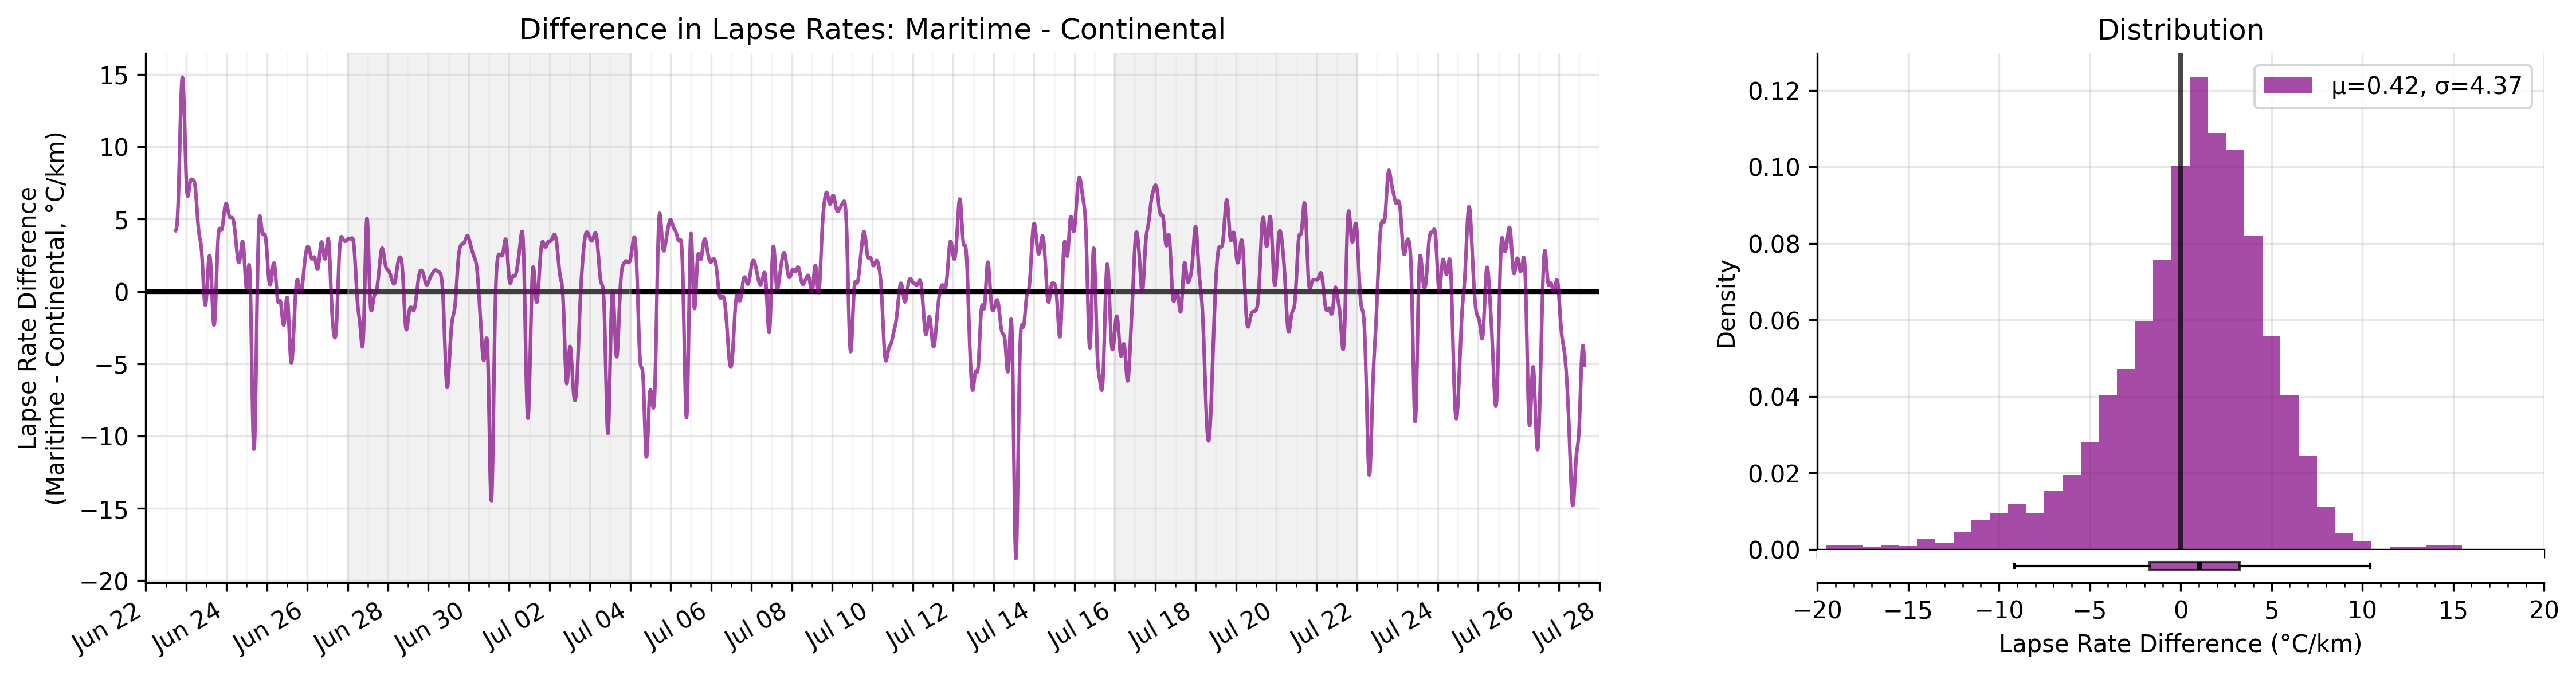

In [9]:
# ============================================================================
# FIGURE 5 (lapse rate difference with histogram)
# ============================================================================

# Create figure with custom gridspec layout
# Left 2/3: Time series
# Right 1/3: Histogram (top) and boxplot (bottom) with 15:2 ratio (thicker boxplot)
fig = plt.figure(figsize=(18, 4), dpi=300)
gs_main = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.2, figure=fig)

# Left panel: Time series
ax_ts = fig.add_subplot(gs_main[0, 0])

# Right panel: Split into histogram and boxplot with 15:1 ratio (thicker boxplot)
gs_right = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=gs_main[0, 1], height_ratios=[15, 1], hspace=0.0
)
ax_hist = fig.add_subplot(gs_right[0, 0])
ax_box = fig.add_subplot(gs_right[1, 0], sharex=ax_hist)

# ============================================================================
# LEFT PANEL: Time series with filtering (Figure 4 style)
# ============================================================================

# Calculate lapse rate difference
lapse_diff_raw = (ds.maritime_lapse_rate - ds.continental_lapse_rate) * 1000

# Apply Butterworth filter to difference
lapse_diff_filtered = butterworth_filter(
    lapse_diff_raw.values,
    fs=FILTER_FS,
    order=FILTER_ORDER,
    lower=FILTER_LOWER,
    upper=FILTER_UPPER * 1 / 2,
)
lapse_diff_filtered_da = xr.DataArray(
    lapse_diff_filtered, coords=lapse_diff_raw.coords, dims=lapse_diff_raw.dims
)

# Add thick black line at zero
ax_ts.axhline(y=0, color="black", linewidth=2, zorder=1)

# Add shaded regions for periods of interest (from Figure 4)
ax_ts.axvspan(june_end_start, june_end_end, alpha=0.3, color="lightgrey", zorder=2)
ax_ts.axvspan(july_mid_start, july_mid_end, alpha=0.3, color="lightgrey", zorder=2)

# Plot filtered lapse rate difference
lapse_diff_filtered_da.plot(
    ax=ax_ts, color=DIFFERENCE_COLOR, alpha=0.7, linewidth=1.5, zorder=3
)

# Set formatting like Figure 4
ax_ts.xaxis.set_major_locator(DayLocator())
ax_ts.xaxis.set_minor_locator(HourLocator(interval=12))
ax_ts.xaxis.set_major_formatter(DateFormatter("%b %d"))

# Get all the tick labels and set every other one to empty
labels = ax_ts.get_xticklabels()
for i, label in enumerate(labels):
    if i % 2 == 1:  # Hide every other label (odd indices)
        label.set_visible(False)

plt.setp(ax_ts.xaxis.get_majorticklabels(), rotation=30, ha="right")

ax_ts.set_ylabel("Lapse Rate Difference\n(Maritime - Continental, °C/km)")
ax_ts.set_title("Difference in Lapse Rates: Maritime - Continental")
ax_ts.set_xlim(full_period_start, full_period_end)
ax_ts.grid(True, alpha=0.3, which="major")
ax_ts.grid(True, alpha=0.1, which="minor")
ax_ts.set_axisbelow(True)
ax_ts.set_xlabel("")
ax_ts.spines["top"].set_visible(False)
ax_ts.spines["right"].set_visible(False)

# ============================================================================
# RIGHT PANEL: Histogram and boxplot (Figure 3 style)
# ============================================================================

# Calculate statistics for difference
difference_clean = lapse_diff_raw.dropna("datetime")
diff_mean = float(difference_clean.mean())
diff_std = float(difference_clean.std())

# Define bin size
bin_size = 1.0
diff_min, diff_max = float(difference_clean.min()), float(difference_clean.max())
diff_bins = np.arange(diff_min - bin_size / 2, diff_max + bin_size, bin_size)

# Histogram
difference_color = DIFFERENCE_COLOR
ax_hist.hist(
    difference_clean.values,
    bins=diff_bins,
    alpha=0.7,
    color=difference_color,
    density=True,
    label=f"μ={diff_mean:.2f}, σ={diff_std:.2f}",
)

# Add zero line
ax_hist.axvline(x=0, color="black", linewidth=2, zorder=1, alpha=0.7)

ax_hist.set_ylabel("Density")
ax_hist.set_title("Distribution")
ax_hist.legend()
ax_hist.grid(True, alpha=0.3)
ax_hist.set_axisbelow(True)
ax_hist.spines["top"].set_visible(False)
ax_hist.spines["right"].set_visible(False)
ax_hist.set_xlim(-20, 20)
ax_hist.tick_params(labelbottom=False)
ax_hist.xaxis.set_major_locator(MultipleLocator(5))
ax_hist.xaxis.set_minor_locator(MultipleLocator(1))

# Boxplot
box = ax_box.boxplot(
    [difference_clean.values],
    positions=[0.5],
    vert=False,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)
box["boxes"][0].set_facecolor(DIFFERENCE_COLOR)
box["boxes"][0].set_alpha(0.7)
box["medians"][0].set_color("black")
box["medians"][0].set_linewidth(2)

ax_box.set_xlim(ax_hist.get_xlim())
ax_box.set_ylim(-0.5, 1.5)
ax_box.set_xlabel("Lapse Rate Difference (°C/km)")
ax_box.set_yticks([])
ax_box.spines["top"].set_visible(False)
ax_box.spines["right"].set_visible(False)
ax_box.spines["left"].set_visible(False)

Maritime median:  <xarray.DataArray 'maritime_lapse_rate' ()> Size: 8B
array(-2.94865104)
Continental median:  <xarray.DataArray 'continental_lapse_rate' ()> Size: 8B
array(-3.93830715)
Lapse Rate Statistics (°C/km):
Maritime: -2.122 ± 4.770
Continental: -2.541 ± 5.000
Difference (Maritime - Continental): 0.419 ± 4.373


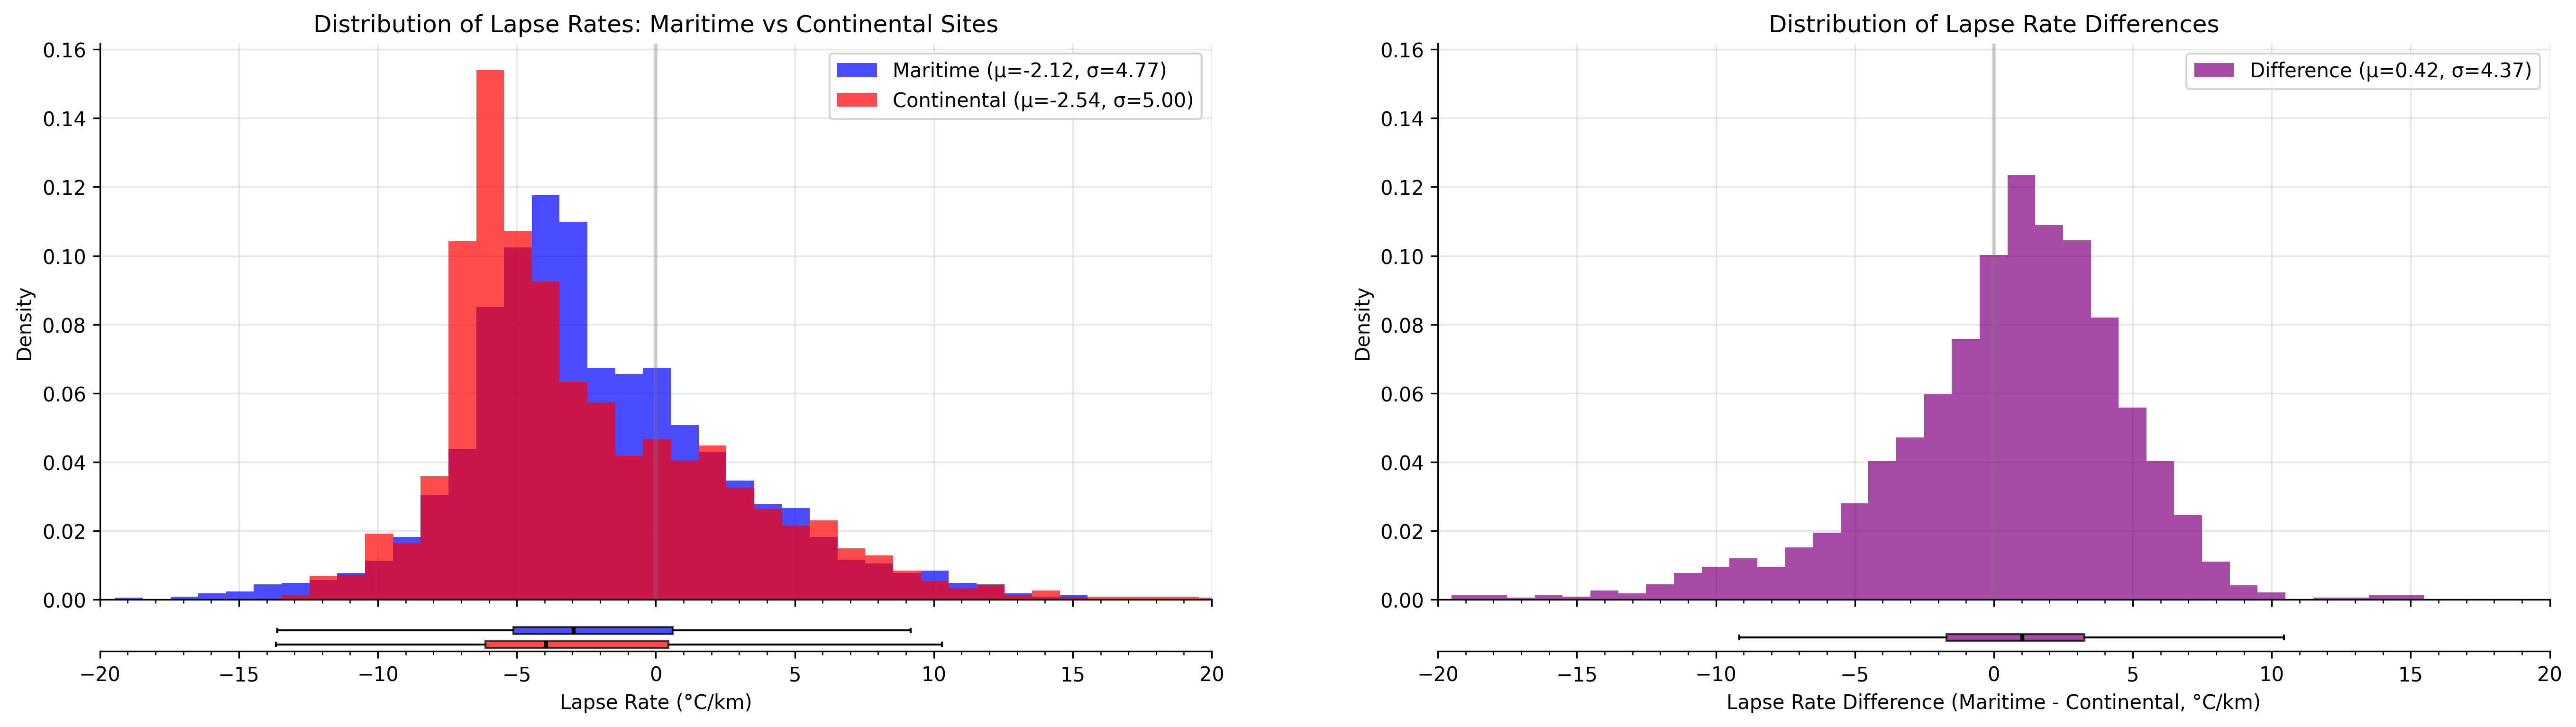

In [10]:
# ============================================================================
# FIGURE 3 (Histograms)
# ============================================================================

# print some statistics
# print("Maritime median: ", maritime_clean.median())
# print("Continental median: ", continental_clean.median())


# Color configuration for histograms
maritime_color = MARITIME_COLOR
continental_color = CONTINENTAL_COLOR
difference_color = DIFFERENCE_COLOR

# Plot 1: Histogram Analysis of Lapse Rates
# Side-by-side layout with percentile range strips below

fig = plt.figure(figsize=(18, 5), dpi=300, layout="constrained")
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 1], hspace=0.0, wspace=0.1, figure=fig)

# Main histogram panels (share both x and y axes)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharex=ax1, sharey=ax1)

# Boxplot strips (share x-axis with main panels)
ax1_range = fig.add_subplot(gs[1, 0], sharex=ax1)
ax2_range = fig.add_subplot(gs[1, 1], sharex=ax2)

# Convert lapse rates to °C/km for better readability
maritime_lapse_km = ds.maritime_lapse_rate * 1000
continental_lapse_km = ds.continental_lapse_rate * 1000
lapse_difference_km = maritime_lapse_km - continental_lapse_km

# Remove NaN values for histogram calculation
maritime_clean = maritime_lapse_km.dropna("datetime")
continental_clean = continental_lapse_km.dropna("datetime")
difference_clean = lapse_difference_km.dropna("datetime")

# print some statistics
print("Maritime median: ", maritime_clean.median())
print("Continental median: ", continental_clean.median())

# Calculate statistics
mar_mean = float(maritime_clean.mean())
mar_std = float(maritime_clean.std())
cont_mean = float(continental_clean.mean())
cont_std = float(continental_clean.std())
diff_mean = float(difference_clean.mean())
diff_std = float(difference_clean.std())

# Define bin size (0.5 °C/km)
bin_size = 1.0

# Calculate bin ranges
mar_min, mar_max = float(maritime_clean.min()), float(maritime_clean.max())
cont_min, cont_max = float(continental_clean.min()), float(continental_clean.max())
diff_min, diff_max = float(difference_clean.min()), float(difference_clean.max())

# Create bins for overlapping histograms
overlap_min = min(mar_min, cont_min)
overlap_max = max(mar_max, cont_max)
overlap_bins = np.arange(overlap_min - bin_size / 2, overlap_max + bin_size, bin_size)

# Create bins for difference histogram
diff_bins = np.arange(diff_min - bin_size / 2, diff_max + bin_size, bin_size)

# Left panel: Overlapping histograms
ax1.hist(
    maritime_clean.values,
    bins=overlap_bins,
    alpha=0.7,
    color=maritime_color,
    density=True,
    label=f"Maritime (μ={mar_mean:.2f}, σ={mar_std:.2f})",
)
ax1.hist(
    continental_clean.values,
    bins=overlap_bins,
    alpha=0.7,
    color=continental_color,
    density=True,
    label=f"Continental (μ={cont_mean:.2f}, σ={cont_std:.2f})",
)

# Add zero line (only in histogram, not extending to boxplot)
ax1.axvline(x=0, color="grey", linewidth=2, zorder=1, alpha=0.3)

ax1.set_ylabel("Density")
ax1.set_title("Distribution of Lapse Rates: Maritime vs Continental Sites")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_axisbelow(True)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xlim(-20, 20)
# Remove x-axis labels (will be on bottom strip)
ax1.tick_params(labelbottom=False)

# Set x-axis locators
from matplotlib.ticker import MultipleLocator

ax1.xaxis.set_major_locator(MultipleLocator(5))
ax1.xaxis.set_minor_locator(MultipleLocator(1))

# Right panel: Difference histogram
ax2.hist(
    difference_clean.values,
    bins=diff_bins,
    alpha=0.7,
    color=difference_color,
    density=True,
    label=f"Difference (μ={diff_mean:.2f}, σ={diff_std:.2f})",
)

# Add zero line (only in histogram, not extending to boxplot)
ax2.axvline(x=0, color="grey", linewidth=2, zorder=1, alpha=0.3)

ax2.set_ylabel("Density")
ax2.set_title("Distribution of Lapse Rate Differences")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_axisbelow(True)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
# Remove x-axis labels (will be on bottom strip)
ax2.tick_params(labelbottom=False)

# Set x-axis locators (shared with ax1)
ax2.xaxis.set_major_locator(MultipleLocator(5))
ax2.xaxis.set_minor_locator(MultipleLocator(1))

# ============================================================================
# BOXPLOT STRIPS (Bottom row)
# ============================================================================

# Left panel boxplots: Maritime vs Continental
box1 = ax1_range.boxplot(
    [maritime_clean.values],
    positions=[1],
    vert=False,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)
box1["boxes"][0].set_facecolor(maritime_color)
box1["boxes"][0].set_alpha(0.7)
box1["medians"][0].set_color("black")
box1["medians"][0].set_linewidth(2)

box2 = ax1_range.boxplot(
    [continental_clean.values],
    positions=[0],
    vert=False,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)
box2["boxes"][0].set_facecolor(continental_color)
box2["boxes"][0].set_alpha(0.7)
box2["medians"][0].set_color("black")
box2["medians"][0].set_linewidth(2)

ax1_range.set_xlim(ax1.get_xlim())
ax1_range.set_ylim(-0.5, 1.5)
ax1_range.set_xlabel("Lapse Rate (°C/km)")
ax1_range.set_yticks([])
ax1_range.spines["top"].set_visible(False)
ax1_range.spines["right"].set_visible(False)
ax1_range.spines["left"].set_visible(False)

# Right panel boxplot: Difference
box3 = ax2_range.boxplot(
    [difference_clean.values],
    positions=[0.5],
    vert=False,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)
box3["boxes"][0].set_facecolor(difference_color)
box3["boxes"][0].set_alpha(0.7)
box3["medians"][0].set_color("black")
box3["medians"][0].set_linewidth(2)

ax2_range.set_xlim(ax2.get_xlim())
ax2_range.set_ylim(-0.5, 1.5)
ax2_range.set_xlabel("Lapse Rate Difference (Maritime - Continental, °C/km)")
ax2_range.set_yticks([])
ax2_range.spines["top"].set_visible(False)
ax2_range.spines["right"].set_visible(False)
ax2_range.spines["left"].set_visible(False)


print(f"Lapse Rate Statistics (°C/km):")
print(f"Maritime: {mar_mean:.3f} ± {mar_std:.3f}")
print(f"Continental: {cont_mean:.3f} ± {cont_std:.3f}")
print(f"Difference (Maritime - Continental): {diff_mean:.3f} ± {diff_std:.3f}")

In [ ]:
# ============================================================================
# FIGURE 1
# ============================================================================

import cmocean


def get_colormap_range(colormap, n_colors, start_frac=0.0, end_frac=1.0):
    """
    Extract colors from a specified range of a colormap.

    Parameters:
    -----------
    colormap : matplotlib colormap
        The colormap to sample from
    n_colors : int
        Number of colors to extract
    start_frac : float, default 0.0
        Starting fraction of colormap (0.0 = beginning)
    end_frac : float, default 1.0
        Ending fraction of colormap (1.0 = end)

    Returns:
    --------
    colors : array
        Array of RGBA color values
    """
    # Create linearly spaced values within the specified range
    color_positions = np.linspace(start_frac, end_frac, n_colors)
    return colormap(color_positions)


# Configuration - easy to modify
selected_sites = ["A07", "A06", "A05"]  # Sites to include in plots (plotting order)
row_order = [0, 1, 2]  # Can change order: 0=full period, 1=zoom periods, 2=lapse rates

# Get midnight prior to first datetime
full_period_start = pd.Timestamp(ds["datetime"].values[0]).floor("D")
# Get midnight after last datetime
full_period_end = pd.Timestamp(ds["datetime"].values[-1]).ceil("D")

# Time periods (redefined from Figure 4)
june_end_start = pd.Timestamp("2025-06-26")
june_end_end = pd.Timestamp("2025-07-01")
june_end_slice = slice(june_end_start, june_end_end)

july_mid_start = pd.Timestamp("2025-07-17")
july_mid_end = pd.Timestamp("2025-07-22")
july_mid_slice = slice(july_mid_start, july_mid_end)

# Plot layout (add spacing like Figure 4)
fig = plt.figure(figsize=(18, 12), dpi=300, layout="constrained")
gs = gridspec.GridSpec(3, 2, height_ratios=[2, 1, 1], hspace=0.05, wspace=0, figure=fig)

# Get temperature data for selected sites
n_sites = len(selected_sites)
# Use maritime colors from the configured color scheme
colors = (
    MARITIME_COLORS[:n_sites]
    if n_sites <= len(MARITIME_COLORS)
    else [get_maritime_color(i) for i in range(n_sites)]
)

maritime_sites_data = {}
site_elevations = {}
for i, site in enumerate(selected_sites):
    site_data = ds.where(ds.site_id == site, drop=True)
    if len(site_data.sensor_idx) > 0:
        maritime_sites_data[site] = site_data.temp_c.mean("sensor_idx")
        site_elevations[site] = float(site_data.elevation.mean().values)

# Row arrangement based on row_order
row_configs = {
    0: {"title": "Full Period", "setup": "full_period"},
    1: {"title": "Lapse Rates", "setup": "lapse_rates"},
    2: {"title": "Zoom Periods", "setup": "zoom_periods"},
}

for row_idx, config_idx in enumerate(row_order):
    config = row_configs[config_idx]

    if config["setup"] == "full_period":
        # Full period timeseries (spans both columns)
        ax = fig.add_subplot(gs[row_idx, :])

        # Add shaded regions for zoom periods
        ax.axvspan(june_end_start, june_end_end, alpha=0.3, color="lightgrey", zorder=2)
        ax.axvspan(july_mid_start, july_mid_end, alpha=0.3, color="lightgrey", zorder=2)

        for i, (site, temp_data) in enumerate(maritime_sites_data.items()):
            elev = site_elevations[site]
            # Apply Butterworth filter to temperature data
            temp_filtered = butterworth_filter(
                temp_data.values,
                fs=FILTER_FS,
                order=FILTER_ORDER,
                lower=FILTER_LOWER,
                upper=FILTER_UPPER,
            )
            temp_data_filtered = xr.DataArray(
                temp_filtered, coords=temp_data.coords, dims=temp_data.dims
            )
            temp_data_filtered.plot(
                ax=ax, color=colors[i], label=f"{site} - {elev:.0f}m", zorder=3
            )

        ax.set_title("Maritime Sites Temperature Timeseries - Full Period")
        ax.set_ylabel("Temperature (°C)")
        ax.set_xlabel("")
        ax.legend()
        ax.set_xlim(full_period_start, full_period_end)
        ax.grid(True, alpha=0.3, which="major")
        ax.grid(True, alpha=0.1, which="minor")
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Set x-axis locators and formatting (like Figure 4)
        ax.xaxis.set_major_locator(DayLocator())
        ax.xaxis.set_minor_locator(HourLocator(interval=12))
        ax.xaxis.set_major_formatter(DateFormatter("%b %d"))

        # Get all the tick labels and set every other one to empty
        labels = ax.get_xticklabels()
        for i, label in enumerate(labels):
            if i % 2 == 1:  # Hide every other label (odd indices)
                label.set_visible(False)

        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

    elif config["setup"] == "zoom_periods":
        # Two side-by-side zoom periods
        ax_left = fig.add_subplot(gs[row_idx, 0])
        ax_right = fig.add_subplot(gs[row_idx, 1], sharey=ax_left)

        zoom_axes = [ax_left, ax_right]
        zoom_periods = [
            (june_end_slice, "Last 5 Days of June"),
            (july_mid_slice, "July 17-22"),
        ]

        for ax, (time_slice, title_suffix) in zip(zoom_axes, zoom_periods):
            for i, (site, temp_data) in enumerate(maritime_sites_data.items()):
                elev = site_elevations[site]
                subset_temp_data = temp_data.sel(datetime=time_slice).dropna(
                    dim="datetime"
                )
                subset_temp_data.plot(
                    ax=ax, color=colors[i], label=f"{site} - {elev:.0f}m", zorder=3
                )

            ax.set_title(f"Maritime Sites Temperature - {title_suffix}")
            ax.set_ylabel("Temperature (°C)")
            ax.set_xlabel("Time")
            ax.set_xlim(
                subset_temp_data.datetime.min(), subset_temp_data.datetime.max()
            )
            ax.grid(True, alpha=0.3, which="major")
            ax.grid(True, alpha=0.1, which="minor")
            ax.set_axisbelow(True)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            # Set axis locators and formatting (like Figure 4)
            ax.yaxis.set_major_locator(MultipleLocator(5))
            ax.yaxis.set_minor_locator(MultipleLocator(1))
            ax.xaxis.set_major_locator(DayLocator())
            ax.xaxis.set_minor_locator(HourLocator(interval=12))
            ax.xaxis.set_major_formatter(DateFormatter("%b %d"))
            # Rotate labels
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

    elif config["setup"] == "lapse_rates":
        # Lapse rate timeseries (spans both columns)
        ax = fig.add_subplot(gs[row_idx, :])

        # Add grey zero line (only for lapse rate plots)
        ax.axhline(y=0, color="grey", linewidth=1.5, zorder=1)

        # Plot overall maritime lapse rate with filtering
        maritime_lapse = ds.maritime_lapse_rate * 1000
        # Apply Butterworth filter to lapse rate data
        maritime_lapse_filtered = butterworth_filter(
            maritime_lapse.values,
            fs=FILTER_FS,
            order=FILTER_ORDER,
            lower=FILTER_LOWER,
            upper=FILTER_UPPER,
        )
        maritime_lapse_filtered_da = xr.DataArray(
            maritime_lapse_filtered,
            coords=maritime_lapse.coords,
            dims=maritime_lapse.dims,
        )
        maritime_lapse_filtered_da.plot(
            ax=ax,
            color="black",
            label="All maritime sites regression",
            linewidth=2,
            alpha=0.8,
            zorder=3,
        )
        ax.fill_between(
            ds.datetime,
            0,
            maritime_lapse_filtered_da,
            where=(maritime_lapse_filtered_da > 0),
            color="lightgrey",
            label="Inverted",
            zorder=0.1,
        )

        ylims = (-20, 20)
        ax.set_ylim(ylims)
        ax.set_ylabel("Lapse Rate (°C/km)")
        ax.set_xlabel("Time")
        ax.legend(loc="upper right")
        ax.set_xlim(full_period_start, full_period_end)
        ax.grid(True, alpha=0.3, which="major")
        ax.grid(True, alpha=0.1, which="minor")
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Set axis locators and formatting (like Figure 4)
        ax.yaxis.set_major_locator(MultipleLocator(5))
        ax.yaxis.set_minor_locator(MultipleLocator(1))
        ax.xaxis.set_major_locator(DayLocator())
        ax.xaxis.set_minor_locator(HourLocator(interval=12))
        ax.xaxis.set_major_formatter(DateFormatter("%b %d"))
        # Hide every other label for cleaner appearance
        for i, label in enumerate(ax.xaxis.get_majorticklabels()):
            if i % 2 == 1:
                label.set_visible(False)
        # Rotate labels
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")


plt.savefig(
    output_dir / "Fig1_maritime_sites_analysis.png", dpi=300, bbox_inches="tight"
)
plt.show()


print("Maritime sites analysis completed!")

In [ ]:
# ============================================================================
# FIGURE 2: Continental Sites Analysis (matching Figure 1 layout)
# ============================================================================

# Configuration - easy to modify
selected_continental_sites = [
    "Divide",
    "Lee1",
    "Lee2",
]  # Sites to include in plots (plotting order)
continental_row_order = [
    0,
    1,
    2,
]  # Can change order: 0=full period, 1=zoom periods, 2=lapse rates

# Plot layout (matching Figure 1)
fig = plt.figure(figsize=(18, 12), dpi=300, layout="constrained")
gs = gridspec.GridSpec(3, 2, height_ratios=[2, 1, 1], hspace=0.05, wspace=0, figure=fig)

# Get temperature data for selected continental sites
n_cont_sites = len(selected_continental_sites)
# Use continental colors from the configured color scheme
cont_colors = (
    CONTINENTAL_COLORS[:n_cont_sites]
    if n_cont_sites <= len(CONTINENTAL_COLORS)
    else [get_continental_color(i) for i in range(n_cont_sites)]
)

continental_sites_data = {}
continental_site_elevations = {}
for i, site in enumerate(selected_continental_sites):
    site_data = ds.where(ds.site_id == site, drop=True)
    if len(site_data.sensor_idx) > 0:
        continental_sites_data[site] = site_data.temp_c.mean("sensor_idx")
        continental_site_elevations[site] = float(site_data.elevation.mean().values)

# Row arrangement based on continental_row_order
for row_idx, config_idx in enumerate(continental_row_order):
    config = row_configs[config_idx]

    if config["setup"] == "full_period":
        # Full period timeseries (spans both columns)
        ax = fig.add_subplot(gs[row_idx, :])

        # Add shaded regions for zoom periods
        ax.axvspan(june_end_start, june_end_end, alpha=0.3, color="lightgrey", zorder=2)
        ax.axvspan(july_mid_start, july_mid_end, alpha=0.3, color="lightgrey", zorder=2)

        for i, (site, temp_data) in enumerate(continental_sites_data.items()):
            elev = continental_site_elevations[site]
            # Apply Butterworth filter to temperature data
            temp_filtered = butterworth_filter(
                temp_data.values,
                fs=FILTER_FS,
                order=FILTER_ORDER,
                lower=FILTER_LOWER,
                upper=FILTER_UPPER,
            )
            temp_data_filtered = xr.DataArray(
                temp_filtered, coords=temp_data.coords, dims=temp_data.dims
            )
            temp_data_filtered.plot(
                ax=ax, color=cont_colors[i], label=f"{site} - {elev:.0f}m", zorder=3
            )

        ax.set_title("Continental Sites Temperature Timeseries - Full Period")
        ax.set_ylabel("Temperature (°C)")
        ax.set_xlabel("")
        ax.legend()
        ax.set_xlim(full_period_start, full_period_end)
        ax.grid(True, alpha=0.3, which="major")
        ax.grid(True, alpha=0.1, which="minor")
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Set x-axis locators and formatting (like Figure 4)
        ax.xaxis.set_major_locator(DayLocator())
        ax.xaxis.set_minor_locator(HourLocator(interval=12))
        ax.xaxis.set_major_formatter(DateFormatter("%b %d"))

        # Get all the tick labels and set every other one to empty
        labels = ax.get_xticklabels()
        for i, label in enumerate(labels):
            if i % 2 == 1:  # Hide every other label (odd indices)
                label.set_visible(False)

        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

    elif config["setup"] == "zoom_periods":
        # Two side-by-side zoom periods
        ax_left = fig.add_subplot(gs[row_idx, 0])
        ax_right = fig.add_subplot(gs[row_idx, 1], sharey=ax_left)

        zoom_axes = [ax_left, ax_right]
        zoom_periods = [
            (june_end_slice, "Last 5 Days of June"),
            (july_mid_slice, "July 17-22"),
        ]

        for ax, (time_slice, title_suffix) in zip(zoom_axes, zoom_periods):
            for i, (site, temp_data) in enumerate(continental_sites_data.items()):
                elev = continental_site_elevations[site]
                temp_data.sel(datetime=time_slice).plot(
                    ax=ax, color=cont_colors[i], label=f"{site} - {elev:.0f}m", zorder=3
                )

            ax.set_title(f"Continental Sites Temperature - {title_suffix}")
            ax.set_ylabel("Temperature (°C)")
            ax.set_xlabel("Time")
            ax.grid(True, alpha=0.3, which="major")
            ax.grid(True, alpha=0.1, which="minor")
            ax.set_axisbelow(True)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            # Set axis locators and formatting (like Figure 4)
            ax.yaxis.set_major_locator(MultipleLocator(5))
            ax.yaxis.set_minor_locator(MultipleLocator(1))
            ax.xaxis.set_major_locator(DayLocator())
            ax.xaxis.set_minor_locator(HourLocator(interval=12))
            ax.xaxis.set_major_formatter(DateFormatter("%b %d"))
            # Rotate labels
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

    elif config["setup"] == "lapse_rates":
        # Lapse rate timeseries (spans both columns)
        ax = fig.add_subplot(gs[row_idx, :])

        # Add grey zero line (only for lapse rate plots)
        ax.axhline(y=0, color="grey", linewidth=1.5, zorder=1)

        # Plot overall continental lapse rate with filtering
        continental_lapse = ds.continental_lapse_rate * 1000
        # Apply Butterworth filter to lapse rate data
        continental_lapse_filtered = butterworth_filter(
            continental_lapse.values,
            fs=FILTER_FS,
            order=FILTER_ORDER,
            lower=FILTER_LOWER,
            upper=FILTER_UPPER,
        )
        continental_lapse_filtered_da = xr.DataArray(
            continental_lapse_filtered,
            coords=continental_lapse.coords,
            dims=continental_lapse.dims,
        )
        continental_lapse_filtered_da.plot(
            ax=ax,
            color="black",
            label="All continental sites regression",
            linewidth=2,
            alpha=0.8,
            zorder=3,
        )
        ax.fill_between(
            ds.datetime,
            0,
            continental_lapse_filtered_da,
            where=(continental_lapse_filtered_da > 0),
            color="lightgrey",
            label="Inverted",
            zorder=0.1,
        )

        ylims = (-20, 20)
        ax.set_ylim(ylims)
        ax.set_ylabel("Lapse Rate (°C/km)")
        ax.set_xlabel("Time")
        ax.legend(loc="upper right")
        ax.set_xlim(full_period_start, full_period_end)
        ax.grid(True, alpha=0.3, which="major")
        ax.grid(True, alpha=0.1, which="minor")
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Set axis locators and formatting (like Figure 4)
        ax.yaxis.set_major_locator(MultipleLocator(5))
        ax.yaxis.set_minor_locator(MultipleLocator(1))
        ax.xaxis.set_major_locator(DayLocator())
        ax.xaxis.set_minor_locator(HourLocator(interval=12))
        ax.xaxis.set_major_formatter(DateFormatter("%b %d"))
        # Hide every other label for cleaner appearance
        for i, label in enumerate(ax.xaxis.get_majorticklabels()):
            if i % 2 == 1:
                label.set_visible(False)
        # Rotate labels
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.savefig(
    output_dir / "Fig2_continental_sites_analysis.png", dpi=300, bbox_inches="tight"
)
plt.show()

print("Continental sites analysis completed!")

In [ ]:
# ============================================================================
# FIGURE 6: Entire-period lapse rate with scatterplot
# ============================================================================

# Additional Analysis 1: Entire-Period Lapse Rate with Scatterplot
# Calculate mean temperature and std dev for each site over entire overlap period
print("\n" + "=" * 60)
print("ADDITIONAL ANALYSIS: Entire-Period Lapse Rate")
print("=" * 60)

site_stats = {}
for site in sorted(ds.site_id.values):
    site_data = ds.where(ds.site_id == site, drop=True)
    temp_data = site_data.temp_c.dropna("datetime")

    if len(temp_data) > 0:
        site_stats[site] = {
            "elevation": float(site_data.elevation.values[0]),
            "mean_temp": float(temp_data.mean()),
            "std_temp": float(temp_data.std()),
            "n_obs": int(len(temp_data)),
        }

# Separate maritime and continental site statistics
maritime_stats = {
    site: stats for site, stats in site_stats.items() if site in maritime_sites
}
continental_stats = {
    site: stats for site, stats in site_stats.items() if site in continental_sites
}

# Extract data for maritime regression
mar_sites = list(maritime_stats.keys())
mar_elevations = [maritime_stats[site]["elevation"] for site in mar_sites]
mar_mean_temps = [maritime_stats[site]["mean_temp"] for site in mar_sites]
mar_temp_stds = [maritime_stats[site]["std_temp"] for site in mar_sites]

# Extract data for continental regression
cont_sites = list(continental_stats.keys())
cont_elevations = [continental_stats[site]["elevation"] for site in cont_sites]
cont_mean_temps = [continental_stats[site]["mean_temp"] for site in cont_sites]
cont_temp_stds = [continental_stats[site]["std_temp"] for site in cont_sites]

# Perform separate linear regressions
if len(mar_elevations) >= 2:
    mar_slope, mar_intercept, mar_r_value, mar_p_value, mar_std_err = stats.linregress(
        mar_elevations, mar_mean_temps
    )
    print(f"Maritime lapse rate: {mar_slope:.6f} °C/m ({mar_slope * 1000:.3f} °C/km)")
    print(f"Maritime R² = {mar_r_value**2:.3f}, p-value = {mar_p_value:.3e}")
else:
    print("Insufficient maritime sites for regression")
    mar_slope = mar_intercept = mar_r_value = mar_p_value = mar_std_err = np.nan

if len(cont_elevations) >= 2:
    cont_slope, cont_intercept, cont_r_value, cont_p_value, cont_std_err = (
        stats.linregress(cont_elevations, cont_mean_temps)
    )
    print(
        f"Continental lapse rate: {cont_slope:.6f} °C/m ({cont_slope * 1000:.3f} °C/km)"
    )
    print(f"Continental R² = {cont_r_value**2:.3f}, p-value = {cont_p_value:.3e}")
else:
    print("Insufficient continental sites for regression")
    cont_slope = cont_intercept = cont_r_value = cont_p_value = cont_std_err = np.nan

# Create side-by-side scatterplots with separate regressions using Fig 4 style
# Configuration flag for confidence intervals
PLOT_CONFIDENCE_INTERVALS = False
CONFIDENCE_LEVEL = 0.95  # 95% confidence interval

fig = plt.figure(figsize=(12, 5), dpi=300, layout="constrained")
gs = gridspec.GridSpec(1, 2, wspace=0.05, figure=fig)

axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]

# Configure plot data for each panel
plot_configs = [
    {
        "sites": mar_sites,
        "elevations": mar_elevations,
        "mean_temps": mar_mean_temps,
        "temp_stds": mar_temp_stds,
        "slope": mar_slope,
        "intercept": mar_intercept,
        "r_value": mar_r_value,
        "std_err": mar_std_err,
        "color": MARITIME_COLOR,
        "title": "Maritime Sites: Elevation vs Mean Temperature",
    },
    {
        "sites": cont_sites,
        "elevations": cont_elevations,
        "mean_temps": cont_mean_temps,
        "temp_stds": cont_temp_stds,
        "slope": cont_slope,
        "intercept": cont_intercept,
        "r_value": cont_r_value,
        "std_err": cont_std_err,
        "color": CONTINENTAL_COLOR,
        "title": "Continental Sites: Elevation vs Mean Temperature",
    },
]

# Loop over both axes and their configurations
for ax, config in zip(axes, plot_configs):
    sites = config["sites"]
    elevations = config["elevations"]
    mean_temps = config["mean_temps"]
    temp_stds = config["temp_stds"]
    slope = config["slope"]
    intercept = config["intercept"]
    r_value = config["r_value"]
    std_err = config["std_err"]
    color = config["color"]
    title = config["title"]

    # Plot sites with error bars
    if len(sites) > 0:
        for i, site in enumerate(sites):
            ax.errorbar(
                elevations[i],
                mean_temps[i],
                yerr=std_err,
                marker="o",
                markersize=8,
                color=color,
                capsize=5,
                capthick=2,
                alpha=0.8,
            )
            ax.annotate(
                site,
                (elevations[i], mean_temps[i]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=10,
                fontweight="bold",
            )

        # Regression line and confidence interval
        if not np.isnan(slope):
            elev_range = np.linspace(min(elevations), max(elevations), 100)
            reg_line = slope * elev_range + intercept

            # Calculate confidence interval if flag is set
            if PLOT_CONFIDENCE_INTERVALS:
                # Calculate confidence interval for the slope parameter (constant width)
                n = len(elevations)
                dof = n - 2  # degrees of freedom
                t_val = stats.t.ppf(
                    (1 + CONFIDENCE_LEVEL) / 2, dof
                )  # t-value for confidence level

                # Confidence bounds for the slope
                slope_lower = slope - t_val * std_err
                slope_upper = slope + t_val * std_err

                # Create parallel regression lines with different slopes
                ci_lower = slope_lower * elev_range + intercept
                ci_upper = slope_upper * elev_range + intercept

                # Plot confidence interval as shaded region
                ax.fill_between(
                    elev_range,
                    ci_lower,
                    ci_upper,
                    color=color,
                    alpha=0.2,
                    label=f"{int(CONFIDENCE_LEVEL * 100)}% CI: [{slope_lower * 1000:.2f}, {slope_upper * 1000:.2f}] °C/km",
                )

            # Plot regression line on top
            ax.plot(
                elev_range,
                reg_line,
                color=color,
                linestyle="--",
                linewidth=2,
                alpha=0.8,
                label=f"Regression: {slope * 1000:.2f} °C/km",
            )

    # Axis formatting
    ax.set_xlabel("Elevation (m)")
    ax.set_ylabel("Mean Temperature (°C)")
    ax.set_title(title)
    ax.legend(loc="best")
    ax.set_ylim(0, 10)
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.5))
    ax.grid(True, alpha=0.3, which="major")
    ax.grid(True, alpha=0.1, which="minor")
    ax.set_axisbelow(True)
    # Despine the axes (match Fig 4 style)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.savefig(
    output_dir / "Fig6_entire_period_lapse_rate_scatter.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Entire-period scatterplots (maritime and continental) created!")

In [ ]:
# Additional Analysis 2: Day/Night Lapse Rate Analysis
print("\n" + "=" * 60)
print("ADDITIONAL ANALYSIS: Day/Night Lapse Rate Comparison")
print("=" * 60)

# Create day/night masks based on hour of day
# Nighttime: 22:00-04:00 (10p-4a), Daytime: 04:00-22:00 (4a-10p)
hours = ds.datetime.dt.hour
night_mask = (hours >= 22) | (hours < 4)
day_mask = ~night_mask

print(f"Time classification:")
print(f"  Nighttime hours (22:00-04:00): {night_mask.sum().values} observations")
print(f"  Daytime hours (04:00-22:00): {day_mask.sum().values} observations")

# Split data by day/night
ds_night = ds.where(night_mask, drop=True)
ds_day = ds.where(day_mask, drop=True)

# Group by date to calculate daily day/night lapse rates
dates = pd.date_range(start=ds.datetime.values[0], end=ds.datetime.values[-1], freq="D")

daily_lapse_rates = {
    "date": [],
    "maritime_day": [],
    "maritime_night": [],
    "continental_day": [],
    "continental_night": [],
}

for date in dates:
    # Select data for this date
    date_str = date.strftime("%Y-%m-%d")

    # Get day and night data for this specific date
    try:
        day_slice = ds_day.sel(datetime=slice(date_str, date_str))
        night_slice = ds_night.sel(datetime=slice(date_str, date_str))
    except:
        # If date doesn't exist in data, skip
        daily_lapse_rates["date"].append(date)
        daily_lapse_rates["maritime_day"].append(np.nan)
        daily_lapse_rates["maritime_night"].append(np.nan)
        daily_lapse_rates["continental_day"].append(np.nan)
        daily_lapse_rates["continental_night"].append(np.nan)
        continue

    # Calculate lapse rates for day and night periods
    # Day lapse rates
    if len(day_slice.datetime) > 0:
        mar_day_lr = day_slice.maritime_lapse_rate.mean().values
        cont_day_lr = day_slice.continental_lapse_rate.mean().values
    else:
        mar_day_lr = np.nan
        cont_day_lr = np.nan

    # Night lapse rates
    if len(night_slice.datetime) > 0:
        mar_night_lr = night_slice.maritime_lapse_rate.mean().values
        cont_night_lr = night_slice.continental_lapse_rate.mean().values
    else:
        mar_night_lr = np.nan
        cont_night_lr = np.nan

    daily_lapse_rates["date"].append(date)
    daily_lapse_rates["maritime_day"].append(mar_day_lr)
    daily_lapse_rates["maritime_night"].append(mar_night_lr)
    daily_lapse_rates["continental_day"].append(cont_day_lr)
    daily_lapse_rates["continental_night"].append(cont_night_lr)

# Convert to DataFrame and clean
df_daily = pd.DataFrame(daily_lapse_rates)
df_daily = df_daily.dropna()

# Convert to °C/km
for col in ["maritime_day", "maritime_night", "continental_day", "continental_night"]:
    df_daily[col] = df_daily[col] * 1000

print(f"Daily lapse rate statistics (°C/km):")
print(
    f"Maritime - Day: {df_daily['maritime_day'].mean():.2f} ± {df_daily['maritime_day'].std():.2f}"
)
print(
    f"Maritime - Night: {df_daily['maritime_night'].mean():.2f} ± {df_daily['maritime_night'].std():.2f}"
)
print(
    f"Continental - Day: {df_daily['continental_day'].mean():.2f} ± {df_daily['continental_day'].std():.2f}"
)
print(
    f"Continental - Night: {df_daily['continental_night'].mean():.2f} ± {df_daily['continental_night'].std():.2f}"
)

# Create separate maritime and continental day/night comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Maritime time series (top left)
ax1 = axes[0, 0]
ax1.plot(
    df_daily["date"],
    df_daily["maritime_day"],
    "r-",
    label="Maritime Day",
    alpha=0.7,
    marker="o",
    markersize=3,
)
ax1.plot(
    df_daily["date"],
    df_daily["maritime_night"],
    "r--",
    label="Maritime Night",
    alpha=0.7,
    marker="s",
    markersize=3,
)
ax1.set_ylabel("Daily Lapse Rate (°C/km)")
ax1.set_title("Maritime Sites: Day vs Night Lapse Rates Over Time")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color="black", linestyle="-", alpha=0.3)

# Continental time series (top right)
ax2 = axes[0, 1]
ax2.plot(
    df_daily["date"],
    df_daily["continental_day"],
    "b-",
    label="Continental Day",
    alpha=0.7,
    marker="o",
    markersize=3,
)
ax2.plot(
    df_daily["date"],
    df_daily["continental_night"],
    "b--",
    label="Continental Night",
    alpha=0.7,
    marker="s",
    markersize=3,
)
ax2.set_ylabel("Daily Lapse Rate (°C/km)")
ax2.set_title("Continental Sites: Day vs Night Lapse Rates Over Time")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color="black", linestyle="-", alpha=0.3)

# Maritime box plot (bottom left)
ax3 = axes[1, 0]
mar_box_data = [
    df_daily["maritime_day"],
    df_daily["maritime_night"],
]
mar_box_labels = [
    "Day",
    "Night",
]
mar_colors = ["lightcoral", "lightcoral"]

mar_box_plot = ax3.boxplot(mar_box_data, labels=mar_box_labels, patch_artist=True)
for patch, color in zip(mar_box_plot["boxes"], mar_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.set_ylabel("Daily Lapse Rate (°C/km)")
ax3.set_title("Maritime Sites: Day vs Night Distribution")
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color="black", linestyle="-", alpha=0.3)

# Continental box plot (bottom right)
ax4 = axes[1, 1]
cont_box_data = [
    df_daily["continental_day"],
    df_daily["continental_night"],
]
cont_box_labels = [
    "Day",
    "Night",
]
cont_colors = ["lightblue", "lightblue"]

cont_box_plot = ax4.boxplot(cont_box_data, labels=cont_box_labels, patch_artist=True)
for patch, color in zip(cont_box_plot["boxes"], cont_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax4.set_ylabel("Daily Lapse Rate (°C/km)")
ax4.set_title("Continental Sites: Day vs Night Distribution")
ax4.grid(True, alpha=0.3)
ax4.axhline(y=0, color="black", linestyle="-", alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / "day_night_lapse_rates.png", dpi=300, bbox_inches="tight")
plt.close()

print("Day/night lapse rate analysis completed!")

In [ ]:
# ============================================================================
# FIGURE 7: Full Period Lapse Rate Timeseries with Histogram (Figure 5 layout)
# ============================================================================

# Create figure with custom gridspec layout (matching Figure 5)
# Left 2/3: Time series
# Right 1/3: Histogram (top) and boxplot (bottom) with 15:2 ratio (thicker boxplot)
fig = plt.figure(figsize=(18, 4), dpi=300)
gs_main = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.2, figure=fig)

# Left panel: Time series
ax_ts = fig.add_subplot(gs_main[0, 0])

# Right panel: Split into histogram and boxplot with 15:2 ratio (thicker boxplot)
gs_right = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=gs_main[0, 1], height_ratios=[15, 1], hspace=0.0
)
ax_hist = fig.add_subplot(gs_right[0, 0])
ax_box = fig.add_subplot(gs_right[1, 0], sharex=ax_hist)

# ============================================================================
# LEFT PANEL: Time series with filtering (Figure 4 style)
# ============================================================================

# Apply Butterworth filter to maritime and continental lapse rates (same as Figure 4)
# Note: maritime_lapse_filtered_da and continental_lapse_filtered_da were already calculated in Figure 4
# For clarity, we could recalculate them here, but we'll reuse the existing filtered data

# Add thick black line at zero
ax_ts.axhline(y=0, color="black", linewidth=2, zorder=1)

# Add shaded regions for periods of interest (from Figure 4)
ax_ts.axvspan(june_end_start, june_end_end, alpha=0.3, color="lightgrey", zorder=2)
ax_ts.axvspan(july_mid_start, july_mid_end, alpha=0.3, color="lightgrey", zorder=2)

# Plot filtered lapse rates (using Figure 3 colors: maritime=red, continental=blue)
maritime_lapse_filtered_da.plot(
    ax=ax_ts, label="Maritime", color=MARITIME_COLOR, alpha=0.7, linewidth=1.5, zorder=3
)
continental_lapse_filtered_da.plot(
    ax=ax_ts,
    label="Continental",
    color=CONTINENTAL_COLOR,
    alpha=0.7,
    linewidth=1.5,
    zorder=3,
)

# Set formatting like Figure 4
ax_ts.xaxis.set_major_locator(DayLocator())
ax_ts.xaxis.set_minor_locator(HourLocator(interval=12))
ax_ts.xaxis.set_major_formatter(DateFormatter("%b %d"))

# Get all the tick labels and set every other one to empty
labels = ax_ts.get_xticklabels()
for i, label in enumerate(labels):
    if i % 2 == 1:  # Hide every other label (odd indices)
        label.set_visible(False)

plt.setp(ax_ts.xaxis.get_majorticklabels(), rotation=30, ha="right")

ax_ts.set_ylim(-20, 20)
ax_ts.set_ylabel("Lapse Rate (°C/km)")
ax_ts.set_title("Maritime vs. Continental Lapse Rates - Full Period")
ax_ts.set_xlim(full_period_start, full_period_end)
ax_ts.legend(loc="upper left")
ax_ts.grid(True, alpha=0.3, which="major")
ax_ts.grid(True, alpha=0.1, which="minor")
ax_ts.set_axisbelow(True)
ax_ts.set_xlabel("")
ax_ts.spines["top"].set_visible(False)
ax_ts.spines["right"].set_visible(False)

# ============================================================================
# RIGHT PANEL: Histogram and boxplot (Figure 3 style)
# ============================================================================

# Use the clean data that was already calculated for Figure 3
# maritime_clean and continental_clean already exist from Figure 3 code

# Calculate bin range for overlapping histograms (reuse from Figure 3)
bin_size = 1.0
overlap_min = min(float(maritime_clean.min()), float(continental_clean.min()))
overlap_max = max(float(maritime_clean.max()), float(continental_clean.max()))
overlap_bins = np.arange(overlap_min - bin_size / 2, overlap_max + bin_size, bin_size)

# Histogram - overlapping maritime and continental (Figure 3 colors)
ax_hist.hist(
    maritime_clean.values,
    bins=overlap_bins,
    alpha=0.7,
    color=MARITIME_COLOR,
    density=True,
    label=f"Maritime (μ={mar_mean:.2f}, σ={mar_std:.2f})",
)
ax_hist.hist(
    continental_clean.values,
    bins=overlap_bins,
    alpha=0.7,
    color=CONTINENTAL_COLOR,
    density=True,
    label=f"Continental (μ={cont_mean:.2f}, σ={cont_std:.2f})",
)

# Add zero line
ax_hist.axvline(x=0, color="black", linewidth=2, zorder=1, alpha=0.7)

ax_hist.set_ylabel("Density")
ax_hist.set_title("Distribution")
ax_hist.legend()
ax_hist.grid(True, alpha=0.3)
ax_hist.set_axisbelow(True)
ax_hist.spines["top"].set_visible(False)
ax_hist.spines["right"].set_visible(False)
ax_hist.set_xlim(-20, 20)
ax_hist.tick_params(labelbottom=False)
ax_hist.xaxis.set_major_locator(MultipleLocator(5))
ax_hist.xaxis.set_minor_locator(MultipleLocator(1))

# Boxplot - side by side maritime and continental
box1 = ax_box.boxplot(
    [maritime_clean.values],
    positions=[0.3],
    vert=False,
    widths=0.25,
    patch_artist=True,
    showfliers=False,
)
box1["boxes"][0].set_facecolor(MARITIME_COLOR)
box1["boxes"][0].set_alpha(0.7)
box1["medians"][0].set_color("black")
box1["medians"][0].set_linewidth(2)

box2 = ax_box.boxplot(
    [continental_clean.values],
    positions=[0.7],
    vert=False,
    widths=0.25,
    patch_artist=True,
    showfliers=False,
)
box2["boxes"][0].set_facecolor(CONTINENTAL_COLOR)
box2["boxes"][0].set_alpha(0.7)
box2["medians"][0].set_color("black")
box2["medians"][0].set_linewidth(2)

ax_box.set_xlim(ax_hist.get_xlim())
ax_box.set_ylim(0, 1)
ax_box.set_xlabel("Lapse Rate (°C/km)")
ax_box.set_yticks([])
ax_box.spines["top"].set_visible(False)
ax_box.spines["right"].set_visible(False)
ax_box.spines["left"].set_visible(False)

plt.savefig(
    output_dir / "Fig7_full_period_lapse_rates_with_histogram.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Figure 7: Full period lapse rates with histogram created!")